In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
df = pd.read_csv(r"C:\Users\Vido\Desktop\EPL448\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv", low_memory=False)

In [76]:
#add this at EDA if not present
df["int_rate"].agg(["mean", "median"])

mean      13.092829
median    12.620000
Name: int_rate, dtype: float64

In [77]:
feauture_data = [
"hardship_flag","hardship_type","hardship_reason","hardship_status","deferral_term",
"hardship_amount","hardship_start_date","hardship_end_date","payment_plan_start_date",
"hardship_length","hardship_dpd","hardship_loan_status",
"orig_projected_additional_accrued_interest","hardship_payoff_balance_amount",
"hardship_last_payment_amount","disbursement_method","debt_settlement_flag",
"debt_settlement_flag_date","settlement_status","settlement_date",
"settlement_amount","settlement_percentage","settlement_term",
"collection_recovery_fee","last_pymnt_amnt","last_pymnt_d","next_pymnt_d",
"out_prncp","out_prncp_inv","policy_code","recoveries","total_pymnt",
"total_pymnt_inv","total_rec_int","total_rec_late_fee","total_rec_prncp",
"pymnt_plan"
]
#removing future data, not available at the occurance of the debt
df_all_but_future = df.drop(columns=feauture_data) # drop feature data from dataset

df_all_but_future.head(100)

joint_laon_data=[
"dti_joint", "annual_inc_joint", "verification_status_joint", "revol_bal_joint", "sec_app_fico_range_low",
"sec_app_fico_range_high", "sec_app_earliest_cr_line", "sec_app_inq_last_6mths", "sec_app_mort_acc", 
"sec_app_open_acc","sec_app_revol_util", "sec_app_open_act_il","sec_app_num_rev_accts","sec_app_chargeoff_within_12_mths", 
"sec_app_collections_12_mths_ex_med", "sec_app_mths_since_last_major_derog",
]

df_all_but_future_joint = df_all_but_future.drop(columns=joint_laon_data)

obselete_features = [
    "id",
    "initial_list_status",
    "member_id",
    "bc_open_to_buy",#inverse of bc_util
    "last_credit_pull_d",#last time credit was checking by LendingClub
    "desc",
    "funded_amnt_inv",
    "title",
    "url",
    "zip_code",
    "funded_amnt"

]

Proxy_variables=[
    "fico_range_high",
    "fico_range_low",
    "grade",
    "sub_grade",
    "installment",
    "int_rate",
]

df_ex_future_joint_obs_proxy=df_all_but_future_joint.drop(columns=(obselete_features + Proxy_variables))



print(df_ex_future_joint_obs_proxy.shape)

print(df_ex_future_joint_obs_proxy.columns)


exist = [
"addr_state","annual_inc","annual_inc_joint","application_type","dti","dti_joint",
"emp_length","emp_title","funded_amnt","funded_amnt_inv","grade","home_ownership",
"id","initial_list_status","installment","int_rate","issue_d","loan_amnt",
"laon-status","member_id","purpose","pymnt_plan","sub_grade","term","title","url",
"verification_status","zip_code","acc_now_delinq","acc_open_past_24mths","all_util",
"avg_cur_bal","bc_open_to_buy","bc_util","chargeoff_within_12_mths",
"collections_12_mths_ex_med","delinq_2yrs","delinq_amnt","earliest_cr_line",
"fico_range_high","fico_range_low","il_util","inq_fi","inq_last_6mths",
"inq_last_12m","mths_since_recent_inq","last_credit_pull_d","max_bal_bc",
"mo_sin_old_il_acct","mo_sin_old_rev_tl_op","mo_sin_rcnt_rev_tl_op",
"mths_since_rcnt_il","mo_sin_rcnt_tl","mort_acc","mths_since_last_delinq",
"mths_since_last_major_derog","mths_since_last_record","mths_since_recent_bc_dlq",
"mths_since_recent_revol_delinq","num_accts_ever_120_pd","num_actv_bc_tl",
"num_actv_rev_tl","num_bc_sats","num_bc_tl","num_il_tl","num_op_rev_tl",
"num_rev_accts","num_rev_tl_bal_gt_0","num_sats","num_tl_120dpd_2m",
"num_tl_30dpd","num_tl_90g_dpd_24m","num_tl_op_past_12m","open_acc","open_acc_6m",
"open_act_il","open_il_12m","open_il_24m","open_rv_12m","open_rv_24m",
"pct_tl_nvr_dlq","percent_bc_gt_75","pub_rec","pub_rec_bankruptcies","revol_bal",
"revol_util","tax_liens","tot_coll_amt","tot_cur_bal","tot_hi_cred_lim","total_acc",
"total_bal_ex_mort","total_bal_il","total_bc_limit","total_cu_tl",
"total_il_high_credit_limit","total_rev_hi_lim","collection_recovery_fee",
"last_pymnt_amnt","last_pymnt_d","next_pymnt_d","out_prncp","out_prncp_inv",
"policy_code","recoveries","total_pymnt","total_pymnt_inv","total_rec_int",
"total_rec_late_fee","total_rec_prncp","mths_since_recent_bc"
]


remaining_columns = [c for c in df_ex_future_joint_obs_proxy.columns if c not in exist]

# print them
for col in remaining_columns:
    print(col)

    


#for i, text in enumerate(df['desc'].dropna().head(100), 1): # checking some none nan desc to understand if they are usefull. they are not
#    print(f"Row {i}:")
#    print(text)
#    print("\n" + "-"*80 + "\n")

(2260701, 81)
Index(['loan_amnt', 'term', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m',
       'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m',
       'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi',
       'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal',
       'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_

In [78]:
#randomly selective equal amount of fully paid and charged off datas and not getting the joint datas
#df_ex_future_joint_obs_proxy = df_ex_future_joint_obs_proxy()
print(df_ex_future_joint_obs_proxy['application_type'].unique()) # checking application type levels, confirmed its two level
print(df_ex_future_joint_obs_proxy['loan_status'].unique())
#removing all the joint rows filtering by application_type
df_individual_ex_future_joint_obs_proxy = df_ex_future_joint_obs_proxy[df_ex_future_joint_obs_proxy['application_type'] == 'Individual'] #filtering individual applicants only

print(df_individual_ex_future_joint_obs_proxy.shape) #Still a lot of data left
print(df_individual_ex_future_joint_obs_proxy.head(10)) # confirming individual only


#now we have to create a function that get equal amount of charged off and fully payed loans ! we ignore current loan statuses such as current grace period 30 days as we want our target to describe only loans whose final outcome is known
loan_counts = df_individual_ex_future_joint_obs_proxy['loan_status'].value_counts()

print(loan_counts)

temp=df_individual_ex_future_joint_obs_proxy[df_individual_ex_future_joint_obs_proxy['loan_status'].isin(['Fully Paid','Charged Off'])].copy()

temp.head(10) # confirming eveerything is individual and Fully paid charge off only

#balancing data
#seperating Charged off and fully paid ones
charged_off = temp[temp['loan_status'] == 'Charged Off']
fully_paid = temp[temp['loan_status'] == 'Fully Paid']
    
fully_paid_downsampling = fully_paid.sample(262215, random_state=42) # getting 262215 fully paid loans randomly
    
# creating new dataset that represents both cases of target variable 
balanced_df = pd.concat([charged_off, fully_paid_downsampling])
    
# reshufling to avoid charged off going going all to test or train data
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Confirm balanced data     
loan_counts = balanced_df['loan_status'].value_counts()

print(loan_counts)

print(balanced_df.tail(10))





['Individual' 'Joint App' nan]
['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']
(2139958, 81)
    loan_amnt        term                                emp_title emp_length  \
0      3600.0   36 months                                  leadman  10+ years   
1     24700.0   36 months                                 Engineer  10+ years   
3     35000.0   60 months              Information Systems Officer  10+ years   
4     10400.0   60 months                      Contract Specialist    3 years   
5     11950.0   36 months                     Veterinary Tecnician    4 years   
6     20000.0   36 months  Vice President of Recruiting Operations  10+ years   
7     20000.0   36 months                              road driver  10+ years   
8     10000.0   36 months                          SERVICE MANAGER    6 years   
9   

In [79]:
#split and encode missing
#splitting data to test and train datasets
balanced_df=balanced_df.drop(columns=["application_type"]) #is no longer needed as it was used already to filter out the joint applications. 

X = balanced_df.drop(columns=["loan_status"])
Y = balanced_df['loan_status']



from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.80, random_state=1)

X_train = X_train.copy()
X_test = X_test.copy()

X_train



,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
392193,20000.0,60 months,technician,6 years,MORTGAGE,80000.0,Source Verified,Jan-2015,debt_consolidation,LA,25.16,4.0,May-1988,0.0,16.0,NaN,5.0,0.0,7241.0,69.0,20.0,584.0,580.0,0.0,NaN,0.0,0.0,61461.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10500.0,NaN,NaN,NaN,2.0,15365.0,NaN,0.0,0.0,87.0,320.0,8.0,8.0,1.0,76.0,16.0,1.0,16.0,0.0,0.0,1.0,1.0,9.0,5.0,3.0,14.0,1.0,5.0,0.0,0.0,0.0,1.0,80.0,NaN,0.0,0.0,82630.0,61461.0,0.0,72130.0
199618,5400.0,36 months,Counselor,3 years,RENT,45000.0,Verified,Nov-2015,debt_consolidation,CA,13.87,0.0,Jul-2012,1.0,NaN,NaN,8.0,0.0,5463.0,51.5,8.0,539.0,535.0,0.0,NaN,0.0,0.0,15557.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10600.0,NaN,NaN,NaN,6.0,1945.0,77.2,0.0,0.0,21.0,40.0,7.0,7.0,0.0,7.0,NaN,5.0,NaN,0.0,2.0,4.0,2.0,2.0,1.0,7.0,7.0,5.0,8.0,0.0,0.0,0.0,5.0,100.0,50.0,0.0,0.0,25263.0,15557.0,5800.0,14663.0
440877,12950.0,36 months,Commerical billing specailist,10+ years,RENT,44000.0,Source Verified,Mar-2015,debt_consolidation,CA,10.47,0.0,Jan-1987,0.0,NaN,60.0,20.0,1.0,8814.0,40.2,64.0,604.0,600.0,0.0,NaN,0.0,0.0,8814.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21900.0,NaN,NaN,NaN,12.0,518.0,57.1,0.0,0.0,145.0,338.0,12.0,6.0,5.0,12.0,NaN,8.0,NaN,0.0,6.0,11.0,8.0,22.0,11.0,20.0,48.0,11.0,18.0,0.0,0.0,0.0,3.0,100.0,57.1,1.0,0.0,21900.0,8814.0,10700.0,0.0
449111,14900.0,36 months,Driver,10+ years,RENT,34000.0,Verified,Apr-2015,debt_consolidation,TX,17.72,0.0,Nov-2000,0.0,NaN,NaN,7.0,0.0,10091.0,39.1,10.0,519.0,515.0,0.0,NaN,0.0,0.0,17899.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25800.0,NaN,NaN,NaN,4.0,2557.0,47.7,0.0,0.0,44.0,173.0,11.0,5.0,0.0,11.0,NaN,NaN,NaN,0.0,4.0,5.0,5.0,7.0,2.0,6.0,8.0,5.0,7.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,0.0,33800.0,17899.0,21000.0,8000.0
391434,12000.0,36 months,Project Manager,10+ years,MORTGAGE,110000.0,Source Verified,Jan-2016,debt_consolidation,NY,16.03,6.0,Jul-1984,1.0,1.0,NaN,14.0,0.0,32528.0,84.5,31.0,599.0,595.0,0.0,13.0,1.0,0.0,152113.0,3.0,2.0,2.0,2.0,5.0,22538.0,86.0,2.0,4.0,1951.0,85.0,38500.0,0.0,0.0,1.0,6.0,11701.0,99.2,0.0,0.0,123.0,378.0,3.0,3.0,5.0,14.0,1.0,3.0,1.0,0.0,3.0,9.0,3.0,7.0,6.0,11.0,20.0,9.0,14.0,0.0,1.0,2.0,4.0,64.5,100.0,0.0,0.0,219180.0,55066.0,3800.0,26330.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371403,24000.0,60 months,Data Aide,4 years,RENT,65000.0,Source Verified,Aug-2015,credit_card,CA,15.65,1.0,Jun-2003,0.0,14.0,NaN,18.0,0.0,30582.0,33.8,44.0,534.0,530.0,1.0,14.0,0.0,0.0,41275.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90400.0,NaN,NaN,NaN,9.0,2428.0,35.4,0.0,0.0,133.0,146.0,3.0,3.0,0.0,3.0,

### Step 1: Normalize and inspect raw `emp_length`
We first convert `term` to months, standardize the raw `emp_length` labels, and plot the training distribution before any clustering-based filling.


Raw emp_length categories in the training split:
emp_length_norm
0           32957
1           28173
2           38152
3           33745
4           25037
5           26123
6           19428
7           18663
8           19070
9           16005
10         135352
Unknown     26839
Name: count, dtype: int64


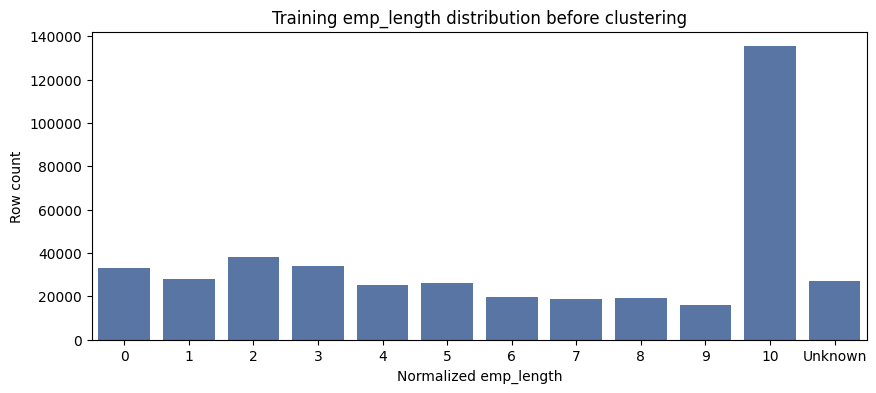

In [80]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Make sure the emp_length figures render inside the notebook.
try:
    plt.switch_backend("module://matplotlib_inline.backend_inline")
except Exception:
    pass

import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Convert loan term strings like "36 months" into integer months.
X_train["term"] = pd.to_numeric(X_train["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce").astype("Int64")
X_test["term"] = pd.to_numeric(X_test["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce").astype("Int64")

# Normalize raw emp_length labels so we can cluster unknown rows using borrower profile features.
def normalize_emp_length(value):
    if pd.isna(value):
        return "Unknown"

    text = str(value).strip()
    if text in ["", "n/a", "N/A", "Unknown"]:
        return "Unknown"

    text = text.replace("years", "").replace("year", "").strip()

    if text.startswith("<"):
        return "0"
    if text.endswith("+"):
        text = text[:-1]

    text = text.replace("+", "").strip()

    try:
        return str(int(text))
    except Exception:
        return "Unknown"


def prepare_emp_length_cluster_frame(frame, dti_fill_value):
    cluster_frame = frame.loc[:, [
        "loan_amnt", "dti", "annual_inc", "open_acc", "total_acc", "revol_bal", "revol_util", "emp_length"
    ]].copy()
    cluster_frame["dti_filled"] = cluster_frame["dti"].fillna(dti_fill_value)
    cluster_frame["revol_util_num"] = pd.to_numeric(
        cluster_frame["revol_util"].astype(str).str.replace("%", "", regex=False),
        errors="coerce"
    ).fillna(0)
    cluster_frame["emp_length_norm"] = cluster_frame["emp_length"].apply(normalize_emp_length)
    cluster_frame["emp_length_is_unknown"] = cluster_frame["emp_length_norm"].eq("Unknown")
    cluster_frame["emp_length_num"] = pd.to_numeric(cluster_frame["emp_length_norm"], errors="coerce")
    return cluster_frame


train_dti_median = X_train["dti"].median()
train_cluster = prepare_emp_length_cluster_frame(X_train, train_dti_median)
test_cluster = prepare_emp_length_cluster_frame(X_test, train_dti_median)

emp_length_order = [str(i) for i in range(0, 11)] + ["Unknown"]
raw_emp_length_counts = train_cluster["emp_length_norm"].value_counts().reindex(emp_length_order, fill_value=0)
print("Raw emp_length categories in the training split:")
print(raw_emp_length_counts)

plt.figure(figsize=(10, 4))
sns.barplot(x=raw_emp_length_counts.index, y=raw_emp_length_counts.values, color="#4C72B0")
plt.title("Training emp_length distribution before clustering")
plt.xlabel("Normalized emp_length")
plt.ylabel("Row count")
plt.show()


### Step 2: Cluster unknown `emp_length` rows
We use borrower profile variables to run KMeans on known employment-length rows, inspect the elbow curve and PCA projection, and then assign unknown rows to the nearest cluster.


Elbow summary for emp_length clustering:
    k  avg_distance_to_centroid
0   1                  2.302531
1   2                  2.043475
2   3                  1.919476
3   4                  1.795034
4   5                  1.790462
5   6                  1.756767
6   7                  1.676983
7   8                  1.626414
8   9                  1.590455
9  10                  1.572691


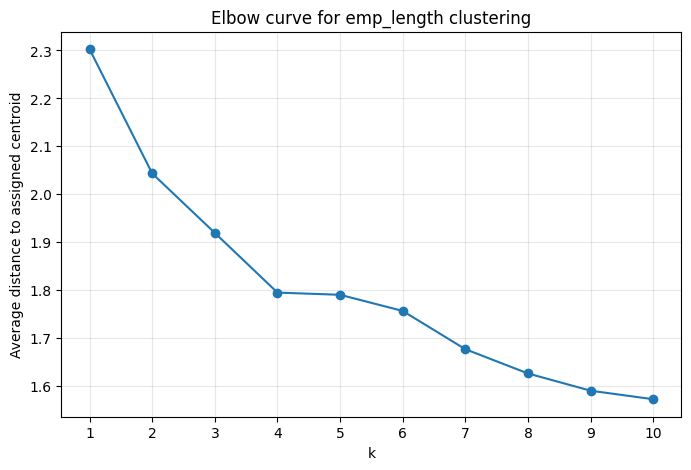

Chosen k for final model: 3


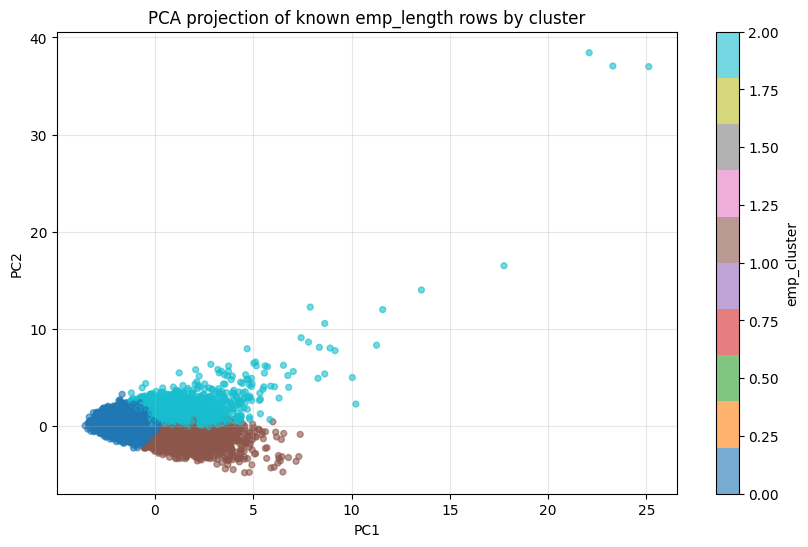

Cluster emp_length summary (known training rows):
             median      mean  mode   count  cluster_to_year
emp_cluster                                                 
0               5.0  5.611220    10  207243                5
1               7.0  6.173358    10  103837                7
2               8.0  6.491884    10   81625                8
Cluster to representative years: {0: 5, 1: 7, 2: 8}
Fallback emp_length for rows without usable cluster features: 6
Training split: filled from nearest cluster = 26839, fallback median used = 0
Test split: filled from nearest cluster = 6674, fallback median used = 0


C:\Users\Vido\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


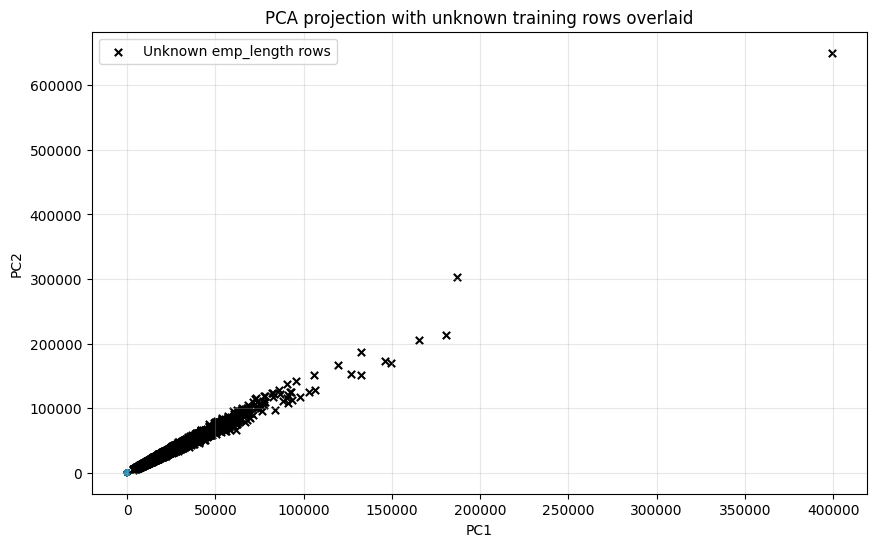

In [ ]:
cluster_features = ["loan_amnt", "dti_filled", "annual_inc", "open_acc", "total_acc", "revol_bal", "revol_util_num"]
known_train = train_cluster.loc[~train_cluster["emp_length_is_unknown"]].dropna(subset=cluster_features).copy()

scaler = StandardScaler()
X_known_scaled = scaler.fit_transform(known_train[cluster_features])

elbow_sample_size = min(50000, len(known_train))
elbow_rng = np.random.RandomState(42)
if len(known_train) > elbow_sample_size:
    elbow_idx = elbow_rng.choice(len(known_train), size=elbow_sample_size, replace=False)
    X_elbow_scaled = X_known_scaled[elbow_idx]
else:
    X_elbow_scaled = X_known_scaled

elbow_k_values = list(range(1, 11))
avg_distance_to_centroid = []
for k in elbow_k_values:
    elbow_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    elbow_labels = elbow_kmeans.fit_predict(X_elbow_scaled)
    elbow_distances = np.linalg.norm(X_elbow_scaled - elbow_kmeans.cluster_centers_[elbow_labels], axis=1)
    avg_distance_to_centroid.append(elbow_distances.mean())

elbow_summary = pd.DataFrame({
    "k": elbow_k_values,
    "avg_distance_to_centroid": avg_distance_to_centroid
})
print("Elbow summary for emp_length clustering:")
print(elbow_summary)

plt.figure(figsize=(8, 5))
plt.plot(elbow_k_values, avg_distance_to_centroid, marker="o")
plt.xticks(elbow_k_values)
plt.xlabel("k")
plt.ylabel("Average distance to assigned centroid")
plt.title("Elbow curve for emp_length clustering")
plt.grid(True, alpha=0.3)
plt.show()

n_clusters = 4
print("Chosen k for final model:", n_clusters)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
known_train["emp_cluster"] = kmeans.fit_predict(X_known_scaled)

pca = PCA(n_components=2, random_state=42)
known_coords = pca.fit_transform(X_known_scaled)
plot_sample_size = min(15000, len(known_train))
plot_idx = elbow_rng.choice(len(known_train), size=plot_sample_size, replace=False) if len(known_train) > plot_sample_size else np.arange(len(known_train))

plt.figure(figsize=(10, 6))
plt.scatter(
    known_coords[plot_idx, 0],
    known_coords[plot_idx, 1],
    c=known_train["emp_cluster"].to_numpy()[plot_idx],
    cmap="tab10",
    s=18,
    alpha=0.6
)
plt.colorbar(label="emp_cluster")
plt.title("PCA projection of known emp_length rows by cluster")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

cluster_summary = known_train.groupby("emp_cluster")["emp_length_num"].agg(
    median="median",
    mean="mean",
    mode=lambda s: int(s.mode().iat[0]),
    count="count"
).sort_index()
cluster_summary["cluster_to_year"] = cluster_summary["median"].round().astype(int)
cluster_to_year = cluster_summary["cluster_to_year"].to_dict()
fallback_emp_length = int(round(known_train["emp_length_num"].median()))

print("Cluster emp_length summary (known training rows):")
print(cluster_summary)
print("Cluster to representative years:", cluster_to_year)
print("Fallback emp_length for rows without usable cluster features:", fallback_emp_length)


def fill_emp_length_from_cluster(cluster_frame, label):
    final_emp_length = pd.to_numeric(cluster_frame["emp_length_norm"], errors="coerce")
    eligible_unknown_mask = cluster_frame["emp_length_is_unknown"] & cluster_frame[cluster_features].notna().all(axis=1)

    if eligible_unknown_mask.any():
        unknown_scaled = scaler.transform(cluster_frame.loc[eligible_unknown_mask, cluster_features])
        distances = np.linalg.norm(unknown_scaled[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2)
        unknown_cluster_ids = pd.Series(np.argmin(distances, axis=1), index=cluster_frame.index[eligible_unknown_mask])
        final_emp_length.loc[eligible_unknown_mask] = unknown_cluster_ids.map(cluster_to_year)
    else:
        unknown_cluster_ids = pd.Series(dtype="int64")

    unresolved_mask = final_emp_length.isna()
    if unresolved_mask.any():
        final_emp_length.loc[unresolved_mask] = fallback_emp_length

    print(f"{label}: filled from nearest cluster = {int(eligible_unknown_mask.sum())}, fallback median used = {int(unresolved_mask.sum())}")
    return final_emp_length.round().astype("Int64"), unknown_cluster_ids


X_train["emp_length"], train_unknown_clusters = fill_emp_length_from_cluster(train_cluster, "Training split")
X_test["emp_length"], test_unknown_clusters = fill_emp_length_from_cluster(test_cluster, "Test split")

if not train_unknown_clusters.empty:
    unknown_coords = pca.transform(train_cluster.loc[train_unknown_clusters.index, cluster_features])
    overlay_sample = min(5000, len(unknown_coords))
    overlay_idx = elbow_rng.choice(len(unknown_coords), size=overlay_sample, replace=False) if len(unknown_coords) > overlay_sample else np.arange(len(unknown_coords))

    plt.figure(figsize=(10, 6))
    plt.scatter(
        known_coords[plot_idx, 0],
        known_coords[plot_idx, 1],
        c=known_train["emp_cluster"].to_numpy()[plot_idx],
        cmap="tab10",
        s=15,
        alpha=0.25
    )
    plt.scatter(
        unknown_coords[overlay_idx, 0],
        unknown_coords[overlay_idx, 1],
        c="black",
        marker="x",
        s=28,
        label="Unknown emp_length rows"
    )
    plt.title("PCA projection with unknown training rows overlaid")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No unknown training rows had complete borrower features for PCA overlay.")


### Step 3: Check the final filled `emp_length` distributions
After the cluster-based fill, we verify that no missing values remain and compare the final train/test `emp_length` distributions.


Remaining missing emp_length values
Train: 0
Test: 0
            train_count  test_count
emp_length                         
0                 32957        8080
1                 28173        7124
2                 38152        9352
3                 33745        8423
4                 25037        6335
5                 43735       10873
6                 19428        4946
7                 25288        6216
8                 21672        5536
9                 16005        3935
10               135352       34066


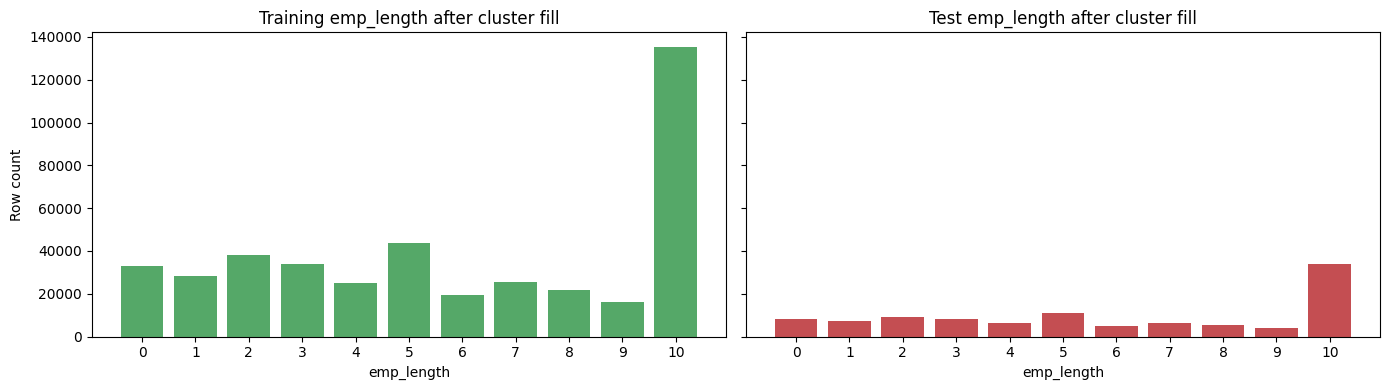

In [82]:
# Quick check after the cluster-based emp_length fill.
print("Remaining missing emp_length values")
print("Train:", int(X_train["emp_length"].isna().sum()))
print("Test:", int(X_test["emp_length"].isna().sum()))

filled_train_counts = X_train["emp_length"].value_counts(dropna=False).sort_index()
filled_test_counts = X_test["emp_length"].value_counts(dropna=False).sort_index()

emp_length_distribution = pd.DataFrame({
    "train_count": filled_train_counts,
    "test_count": filled_test_counts
}).fillna(0).astype(int)
print(emp_length_distribution)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(emp_length_distribution.index.astype(str), emp_length_distribution["train_count"], color="#55A868")
axes[0].set_title("Training emp_length after cluster fill")
axes[0].set_xlabel("emp_length")
axes[0].set_ylabel("Row count")

axes[1].bar(emp_length_distribution.index.astype(str), emp_length_distribution["test_count"], color="#C44E52")
axes[1].set_title("Test emp_length after cluster fill")
axes[1].set_xlabel("emp_length")

plt.tight_layout()
plt.show()


### Step 4: Clean `home_ownership` and `verification_status`
We keep the main `home_ownership` groups, align the target rows after filtering, and then map both columns into the numeric representation used in this preprocessing notebook.


In [83]:
print("home_ownership before filtering")
print(X_train["home_ownership"].value_counts(dropna=False))
print(X_test["home_ownership"].value_counts(dropna=False))

keep_home_ownership = ["MORTGAGE", "RENT", "OWN"]
X_train = X_train[X_train["home_ownership"].isin(keep_home_ownership)].copy()
X_test = X_test[X_test["home_ownership"].isin(keep_home_ownership)].copy()
Y_train = Y_train.loc[X_train.index].copy()
Y_test = Y_test.loc[X_test.index].copy()

home_map = {"RENT": 1, "MORTGAGE": 2, "OWN": 3}
verif_map = {"Not Verified": 1, "Verified": 2, "Source Verified": 3}

X_train["home_ownership"] = X_train["home_ownership"].map(home_map).astype(int)
X_train["verification_status"] = X_train["verification_status"].map(verif_map).astype(int)
X_test["home_ownership"] = X_test["home_ownership"].map(home_map).astype(int)
X_test["verification_status"] = X_test["verification_status"].map(verif_map).astype(int)

print("home_ownership after filtering and mapping")
print(X_train["home_ownership"].value_counts(dropna=False).sort_index())
print(X_test["home_ownership"].value_counts(dropna=False).sort_index())
print("verification_status after mapping")
print(X_train["verification_status"].value_counts(dropna=False).sort_index())
print(X_test["verification_status"].value_counts(dropna=False).sort_index())

# These copied train/test frames still contain the last_fico columns, so drop them here.
X_train = X_train.drop(["last_fico_range_high", "last_fico_range_low"], axis=1)
X_test = X_test.drop(["last_fico_range_high", "last_fico_range_low"], axis=1)

print(X_train[["home_ownership", "verification_status"]].dtypes)
X_train[["home_ownership", "verification_status"]].head()


home_ownership before filtering
home_ownership
MORTGAGE    195358
RENT        178410
OWN          45631
ANY             92
OTHER           44
NONE             9
Name: count, dtype: int64
home_ownership
MORTGAGE    48686
RENT        44685
OWN         11479
ANY            26
OTHER           8
NONE            2
Name: count, dtype: int64
home_ownership after filtering and mapping
home_ownership
1    178410
2    195358
3     45631
Name: count, dtype: int64
home_ownership
1    44685
2    48686
3    11479
Name: count, dtype: int64
verification_status after mapping
verification_status
1    113685
2    139271
3    166443
Name: count, dtype: int64
verification_status
1    28530
2    34733
3    41587
Name: count, dtype: int64
home_ownership         int64
verification_status    int64
dtype: object


,home_ownership,verification_status
392193,2,3
199618,1,2
440877,1,3
449111,1,2
391434,2,3


In [84]:
#Doing a bit more feature engineering/reduction and encoding 
#Instead of keeping both issue_d and earliest_cr_line we create a new more usefull varaible called credit_maturity at time of application
from datetime import datetime

# Function to calculate months
def credit_maturity_months(issue, earliest):
    issue_date = datetime.strptime(issue, "%b-%Y")
    earliest_date = datetime.strptime(earliest, "%b-%Y")
    months = (issue_date.year - earliest_date.year) * 12 + (issue_date.month - earliest_date.month)
    return int(months)

# Apply function to all rows
X_train["credit_maturity"] = X_train.apply(lambda row: credit_maturity_months(row["issue_d"], row["earliest_cr_line"]), axis=1)
X_test["credit_maturity"] = X_test.apply(lambda row: credit_maturity_months(row["issue_d"], row["earliest_cr_line"]), axis=1)
X_test=X_test.drop(['issue_d','earliest_cr_line'], axis=1)
X_train=X_train.drop(['issue_d','earliest_cr_line'], axis=1)
X_test



,loan_amnt,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_maturity
294399,3500.0,36,Driver,4,2,35000.0,1,credit_card,FL,16.12,0.0,0.0,NaN,NaN,12.0,0.0,5642.0,49.5,13.0,0.0,NaN,0.0,0.0,18693.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11400.0,NaN,NaN,NaN,6.0,1558.0,60.5,0.0,0.0,14.0,50.0,6.0,6.0,0.0,7.0,NaN,7.0,NaN,0.0,3.0,8.0,5.0,5.0,1.0,11.0,12.0,8.0,12.0,0.0,0.0,0.0,3.0,100.0,40.0,0.0,0.0,27418.0,18693.0,5800.0,16018.0,50
41612,20000.0,36,Owner,0,1,100000.0,3,debt_consolidation,CA,22.90,0.0,2.0,NaN,74.0,11.0,1.0,10056.0,44.3,16.0,0.0,NaN,0.0,2403.0,104587.0,2.0,2.0,2.0,3.0,1.0,94531.0,NaN,3.0,6.0,6148.0,44.0,22700.0,1.0,0.0,11.0,9.0,9508.0,45.2,0.0,0.0,47.0,115.0,6.0,1.0,0.0,6.0,NaN,0.0,NaN,0.0,4.0,6.0,7.0,8.0,4.0,9.0,10.0,6.0,11.0,0.0,0.0,0.0,5.0,100.0,14.3,0.0,1.0,119837.0,104587.0,20600.0,97137.0,316
348054,18000.0,60,Sr Telecom Analyst,8,1,88691.0,2,credit_card,IL,37.30,2.0,1.0,9.0,61.0,48.0,2.0,40107.0,76.6,75.0,0.0,63.0,0.0,0.0,122655.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52390.0,NaN,NaN,NaN,21.0,2788.0,76.1,0.0,0.0,207.0,100.0,3.0,3.0,1.0,3.0,63.0,1.0,9.0,1.0,10.0,33.0,10.0,16.0,15.0,44.0,59.0,33.0,48.0,0.0,0.0,0.0,3.0,95.4,70.0,2.0,0.0,151179.0,122655.0,11800.0,98789.0,219
507842,20000.0,36,RN Nurse,5,1,52000.0,2,debt_consolidation,TX,4.06,0.0,0.0,NaN,NaN,7.0,0.0,3880.0,13.4,8.0,0.0,NaN,0.0,3598.0,3880.0,1.0,0.0,0.0,1.0,20.0,0.0,NaN,1.0,2.0,1911.0,13.0,28900.0,0.0,0.0,0.0,3.0,554.0,17.4,0.0,0.0,20.0,107.0,5.0,5.0,0.0,5.0,NaN,NaN,NaN,0.0,5.0,6.0,5.0,5.0,1.0,7.0,7.0,6.0,7.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,28900.0,3880.0,21100.0,0.0,107
295828,19000.0,60,Sales Engineer,10,2,60000.0,1,home_improvement,OH,25.86,1.0,0.0,13.0,NaN,11.0,0.0,2243.0,26.4,30.0,0.0,13.0,0.0,929.0,233362.0,0.0,3.0,0.0,1.0,13.0,45340.0,90.0,0.0,0.0,962.0,78.0,8500.0,2.0,0.0,0.0,1.0,25929.0,68.5,0.0,0.0,139.0,555.0,63.0,13.0,4.0,92.0,29.0,13.0,29.0,5.0,2.0,3.0,3.0,7.0,8.0,7.0,18.0,3.0,11.0,0.0,0.0,1.0,0.0,86.2,50.0,0.0,0.0,277381.0,47583.0,2800.0,72704.0,556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154368,30000.0,36,Interior Designer,3,1,85000.0,3,debt_consolidation,CA,12.99,0.0,0.0,NaN,NaN,13.0,0.0,26694.0,76.9,24.0,0.0,NaN,0.0,0.0,30863.0,0.0,6.0,0.0,0.0,26.0,4169.0,19.0,2.0,3.0,14838.0,54.0,34700.0,0.0,0.0,1.0,3.0,2572.0,79.8,0.0,0.0,154.0,155.0,8.0,8.0,0.0,9.0,NaN,9.0,NaN,0.0,3.0,4.0,4.0,7.0,14.0,7.0,10.0,4.0,13.0,0.0,0.0,0.0,2.0,100.0,50.0,0.0,0.0,56700.0,30863.0,21700.0,22000.0,155
446100,24000.0,60,stna,8,2,58000.0,3,debt_consolidation,OH,9.00,0.0,0.0,NaN,101.0,16.0,1.0,3655.0,11.6,26.0,0.0,NaN,0.0,0.0,75665.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31400.0,NaN,NaN,NaN,10.0,5405.0,0.0,0.0,0.0,134.0,117.0,13.0,10.0,2.0,17.

### Step 5: Preserve a CatBoost-friendly branch
Before the original preprocessing path one-hot encodes `purpose` and drops text/categorical columns, we keep a separate copy of the train/test data. This lets us continue the original preprocessing unchanged while also preparing a second branch for our final CatBoost-oriented steps later.


In [85]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
Y_train_cat = Y_train.copy()
Y_test_cat = Y_test.copy()

print("CatBoost branch shapes")
print(X_train_cat.shape, X_test_cat.shape)
print("CatBoost branch key columns")
print(X_train_cat[["home_ownership", "verification_status", "purpose", "emp_title", "addr_state", "credit_maturity"]].dtypes)
X_train_cat[["home_ownership", "verification_status", "purpose", "emp_title", "addr_state", "credit_maturity"]].head()


CatBoost branch shapes
(419399, 76) (104850, 76)
CatBoost branch key columns
home_ownership          int64
verification_status     int64
purpose                object
emp_title              object
addr_state             object
credit_maturity         int64
dtype: object


,home_ownership,verification_status,purpose,emp_title,addr_state,credit_maturity
392193,2,3,debt_consolidation,technician,LA,320
199618,1,2,debt_consolidation,Counselor,CA,40
440877,1,3,debt_consolidation,Commerical billing specailist,CA,338
449111,1,2,debt_consolidation,Driver,TX,173
391434,2,3,debt_consolidation,Project Manager,NY,378


### Step 6: Create `occupation_group` and `purpose_group` for our CatBoost branch
On the CatBoost-friendly copy, we replace the noisy raw job-title signal with a grouped `occupation_group`, and we merge the detailed loan-purpose labels into a smaller `purpose_group`. This keeps the original preprocessing path unchanged while building the grouped categorical features we use later in our own modeling pipeline.


In [86]:
def map_emp_title_to_group(emp_title):
    if pd.isna(emp_title):
        return "unknown"
    title = str(emp_title).strip().lower()
    if not title or title in {"nan", "none"}:
        return "unknown"

    keyword_groups = [
        ("retired", ["retired"]),
        ("student", ["student", "intern"]),
        ("self_employed_business_owner", ["self employed", "self-employed", "owner", "founder", "co-owner", "entrepreneur", "small business", "business owner"]),
        ("government_public_safety", ["government", "city of", "county", "state of", "police", "officer", "sheriff", "fire", "army", "navy", "air force", "marine", "military", "federal", "usps", "postal"]),
        ("healthcare", ["nurse", "rn", "doctor", "physician", "medical", "hospital", "health", "dental", "dentist", "pharmacy", "therap", "clinical", "caregiver"]),
        ("education", ["teacher", "professor", "school", "educat", "principal", "instructor", "faculty", "counselor"]),
        ("finance_accounting", ["account", "finance", "financial", "bank", "banker", "credit", "loan", "underwriter", "analyst", "controller", "auditor", "bookkeeper"]),
        ("engineering_it", ["engineer", "developer", "programmer", "software", "network", "systems", "architect", "cyber", "database", "data scientist", "it support", "help desk"]),
        ("management_administration", ["manager", "management", "director", "supervisor", "administrator", "admin", "coordinator", "executive", "operations", "project manager"]),
        ("sales_marketing_real_estate", ["sales", "marketing", "account executive", "realtor", "real estate", "broker", "leasing"]),
        ("transportation_logistics", ["driver", "truck", "transport", "logistics", "warehouse", "delivery", "shipping", "forklift", "dispatcher"]),
        ("construction_skilled_trade", ["construction", "electric", "plumb", "carpent", "mechanic", "machinist", "welder", "contractor", "installer", "maintenance", "hvac"]),
        ("manufacturing_production", ["manufacturing", "production", "assembler", "operator", "factory", "plant"]),
        ("service_retail_hospitality", ["retail", "cashier", "server", "waiter", "waitress", "bartender", "cook", "chef", "restaurant", "hotel", "customer service", "store"]),
    ]

    for group_name, keywords in keyword_groups:
        for keyword in keywords:
            if keyword in title:
                return group_name
    return "other"

def map_purpose_to_group(purpose):
    if pd.isna(purpose):
        return "unknown"
    purpose = str(purpose).strip().lower()
    if not purpose or purpose in {"nan", "none"}:
        return "unknown"

    purpose_groups = {
        "debt_refinancing": {"credit_card", "debt_consolidation"},
        "housing_related": {"home_improvement", "house", "moving"},
        "major_or_discretionary_purchase": {"car", "major_purchase", "vacation", "wedding"},
        "medical_emergency": {"medical"},
        "business_investment": {"small_business"},
        "education": {"educational"},
        "energy_or_special_project": {"renewable_energy"},
        "other": {"other"},
    }

    for group_name, members in purpose_groups.items():
        if purpose in members:
            return group_name
    return "other"

X_train_cat["occupation_group"] = X_train_cat["emp_title"].apply(map_emp_title_to_group).astype(str)
X_test_cat["occupation_group"] = X_test_cat["emp_title"].apply(map_emp_title_to_group).astype(str)
X_train_cat["purpose_group"] = X_train_cat["purpose"].apply(map_purpose_to_group).astype(str)
X_test_cat["purpose_group"] = X_test_cat["purpose"].apply(map_purpose_to_group).astype(str)

print("Top occupation groups in training data")
print(X_train_cat["occupation_group"].value_counts().head(10))
print("Purpose groups in training data")
print(X_train_cat["purpose_group"].value_counts())
X_train_cat[["emp_title", "occupation_group", "purpose", "purpose_group"]].head(10)


Top occupation groups in training data
occupation_group
other                          140555
management_administration       87795
healthcare                      29570
unknown                         28966
finance_accounting              27049
education                       17256
engineering_it                  15055
government_public_safety        14268
transportation_logistics        13616
sales_marketing_real_estate     11261
Name: count, dtype: int64
Purpose groups in training data
purpose_group
debt_refinancing                   335300
housing_related                     31694
other                               24834
major_or_discretionary_purchase     16542
business_investment                  5706
medical_emergency                    4901
energy_or_special_project             316
education                             106
Name: count, dtype: int64


,emp_title,occupation_group,purpose,purpose_group
392193,technician,other,debt_consolidation,debt_refinancing
199618,Counselor,education,debt_consolidation,debt_refinancing
440877,Commerical billing specailist,other,debt_consolidation,debt_refinancing
449111,Driver,transportation_logistics,debt_consolidation,debt_refinancing
391434,Project Manager,management_administration,debt_consolidation,debt_refinancing
510302,Food Runner,other,debt_consolidation,debt_refinancing
385187,Rail Grading,other,debt_consolidation,debt_refinancing
457544,Educational Diagnostician,education,credit_card,debt_refinancing
5398,branch manager,management_administration,debt_consolidation,debt_refinancing
140640,Shop supervisor,management_administration,credit_card,debt_refinancing


### Step 7: Prepare the CatBoost branch for modeling
This step finishes the CatBoost-friendly branch without touching the original preprocessing path. We restore categorical labels for the encoded columns, drop the raw text columns that were replaced by grouped versions, create missing-value flags for the sparse credit-history fields, and fill the remaining missing values so the branch is ready for later modeling.


In [87]:
HOME_REVERSE_MAP = {1: "RENT", 2: "MORTGAGE", 3: "OWN"}
VERIFICATION_REVERSE_MAP = {1: "Not Verified", 2: "Verified", 3: "Source Verified"}

MONTHS_SINCE_COLUMNS_CAT = [
    "mths_since_last_delinq", "mths_since_last_record", "mths_since_last_major_derog",
    "mths_since_rcnt_il", "mo_sin_old_il_acct", "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl", "mths_since_recent_bc", "mths_since_recent_bc_dlq",
    "mths_since_recent_revol_delinq", "num_bc_sats", "num_sats", "all_util",
    "bc_util", "percent_bc_gt_75", "revol_util", "il_util", "tot_cur_bal",
    "mo_sin_old_rev_tl_op", "mths_since_recent_inq", "pct_tl_nvr_dlq",
    "tot_hi_cred_lim", "total_bc_limit", "num_tl_120dpd_2m"
]

SAFE_TO_FILL_ZERO_CAT = [
    "open_acc_6m", "open_rv_12m", "open_rv_24m", "total_bal_il", "max_bal_bc",
    "inq_fi", "inq_last_12m", "total_cu_tl", "acc_open_past_24mths", "mort_acc",
    "num_accts_ever_120_pd", "num_actv_bc_tl", "num_actv_rev_tl", "num_bc_tl",
    "num_il_tl", "num_op_rev_tl", "open_il_12m", "open_act_il", "open_il_24m",
    "num_rev_tl_bal_gt_0", "num_tl_30dpd", "num_tl_90g_dpd_24m", "num_tl_op_past_12m",
    "total_bal_ex_mort", "total_il_high_credit_limit", "total_rev_hi_lim", "tot_coll_amt",
    "num_rev_accts"
]

X_train_cat_ready = X_train_cat.copy()
X_test_cat_ready = X_test_cat.copy()

X_train_cat_ready["home_ownership"] = X_train_cat_ready["home_ownership"].map(HOME_REVERSE_MAP).fillna(X_train_cat_ready["home_ownership"].astype(str))
X_test_cat_ready["home_ownership"] = X_test_cat_ready["home_ownership"].map(HOME_REVERSE_MAP).fillna(X_test_cat_ready["home_ownership"].astype(str))
X_train_cat_ready["verification_status"] = X_train_cat_ready["verification_status"].map(VERIFICATION_REVERSE_MAP).fillna(X_train_cat_ready["verification_status"].astype(str))
X_test_cat_ready["verification_status"] = X_test_cat_ready["verification_status"].map(VERIFICATION_REVERSE_MAP).fillna(X_test_cat_ready["verification_status"].astype(str))

for column in ["home_ownership", "verification_status", "occupation_group", "purpose_group"]:
    X_train_cat_ready[column] = X_train_cat_ready[column].fillna("unknown").astype(str)
    X_test_cat_ready[column] = X_test_cat_ready[column].fillna("unknown").astype(str)

for column in MONTHS_SINCE_COLUMNS_CAT:
    if column in X_train_cat_ready.columns:
        X_train_cat_ready[f"{column}_is_nan"] = X_train_cat_ready[column].isna().astype(int)
        X_test_cat_ready[f"{column}_is_nan"] = X_test_cat_ready[column].isna().astype(int)
        X_train_cat_ready[column] = X_train_cat_ready[column].fillna(0)
        X_test_cat_ready[column] = X_test_cat_ready[column].fillna(0)

for column in SAFE_TO_FILL_ZERO_CAT:
    if column in X_train_cat_ready.columns:
        X_train_cat_ready[column] = X_train_cat_ready[column].fillna(0)
        X_test_cat_ready[column] = X_test_cat_ready[column].fillna(0)

for column in X_train_cat_ready.select_dtypes(include=["number"]).columns:
    if X_train_cat_ready[column].isna().any() or X_test_cat_ready[column].isna().any():
        fill_value = X_train_cat_ready[column].median()
        if pd.isna(fill_value):
            fill_value = 0
        X_train_cat_ready[column] = X_train_cat_ready[column].fillna(fill_value)
        X_test_cat_ready[column] = X_test_cat_ready[column].fillna(fill_value)

X_train_cat_ready = X_train_cat_ready.drop(columns=["emp_title", "purpose", "addr_state"], errors="ignore")
X_test_cat_ready = X_test_cat_ready.drop(columns=["emp_title", "purpose", "addr_state"], errors="ignore")

CATBOOST_BRANCH_CATEGORICAL_COLUMNS = ["home_ownership", "verification_status", "occupation_group", "purpose_group"]

print("CatBoost-ready branch shapes")
print(X_train_cat_ready.shape, X_test_cat_ready.shape)
print("Remaining missing values in CatBoost branch")
print(int(X_train_cat_ready.isna().sum().sum()), int(X_test_cat_ready.isna().sum().sum()))
print("CatBoost branch categorical columns")
print(CATBOOST_BRANCH_CATEGORICAL_COLUMNS)
X_train_cat_ready[CATBOOST_BRANCH_CATEGORICAL_COLUMNS].head()


CatBoost-ready branch shapes
(419399, 99) (104850, 99)
Remaining missing values in CatBoost branch
0 0
CatBoost branch categorical columns
['home_ownership', 'verification_status', 'occupation_group', 'purpose_group']


,home_ownership,verification_status,occupation_group,purpose_group
392193,MORTGAGE,Source Verified,other,debt_refinancing
199618,RENT,Verified,education,debt_refinancing
440877,RENT,Source Verified,other,debt_refinancing
449111,RENT,Verified,transportation_logistics,debt_refinancing
391434,MORTGAGE,Source Verified,management_administration,debt_refinancing


### Step 8: Rank the CatBoost-branch features and build the final subsets
To show the professor how the final subsets are selected, we compute three ranking signals directly from the training data: feature-target correlation, standardized logistic-regression coefficient importance, and a combined rank that averages the two. From those rankings we derive the four final subset options: `top_10_correlation`, `top_20_combined`, `top_40_importance`, and `full_native_grouped`.


In [88]:
from sklearn.linear_model import LogisticRegression

y_train_cat_binary = Y_train_cat.map({"Fully Paid": 0, "Charged Off": 1}).astype(int)

ranking_train_df = X_train_cat_ready.drop(columns=CATBOOST_BRANCH_CATEGORICAL_COLUMNS, errors="ignore").copy()
for column in ranking_train_df.columns:
    ranking_train_df[column] = pd.to_numeric(ranking_train_df[column], errors="coerce")

if ranking_train_df.isna().sum().sum() > 0:
    ranking_train_df = ranking_train_df.fillna(ranking_train_df.median(numeric_only=True))

ranking_train_df = ranking_train_df.astype(float)

correlation_series = ranking_train_df.apply(lambda column: column.corr(y_train_cat_binary))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(ranking_train_df)
log_reg = LogisticRegression(max_iter=2000, solver="liblinear", random_state=42)
log_reg.fit(X_train_scaled, y_train_cat_binary)
coefficient_series = pd.Series(log_reg.coef_[0], index=ranking_train_df.columns)

feature_ranking_df = pd.DataFrame({
    "feature": ranking_train_df.columns,
    "correlation": correlation_series.reindex(ranking_train_df.columns).values,
    "coefficient": coefficient_series.reindex(ranking_train_df.columns).values,
})
feature_ranking_df["abs_correlation"] = feature_ranking_df["correlation"].abs()
feature_ranking_df["abs_coefficient"] = feature_ranking_df["coefficient"].abs()
feature_ranking_df["correlation_rank"] = feature_ranking_df["abs_correlation"].rank(method="dense", ascending=False)
feature_ranking_df["importance_rank"] = feature_ranking_df["abs_coefficient"].rank(method="dense", ascending=False)
feature_ranking_df["combined_rank"] = (feature_ranking_df["correlation_rank"] + feature_ranking_df["importance_rank"]) / 2

feature_ranking_by_correlation = feature_ranking_df.sort_values(["abs_correlation", "abs_coefficient"], ascending=[False, False]).reset_index(drop=True)
feature_ranking_by_importance = feature_ranking_df.sort_values(["abs_coefficient", "abs_correlation"], ascending=[False, False]).reset_index(drop=True)
feature_ranking_by_combined = feature_ranking_df.sort_values(["combined_rank", "abs_correlation", "abs_coefficient"], ascending=[True, False, False]).reset_index(drop=True)

print("Top features by absolute correlation")
display(feature_ranking_by_correlation[["feature", "correlation", "abs_correlation", "correlation_rank"]].head(20))
print("Top features by logistic coefficient importance")
display(feature_ranking_by_importance[["feature", "coefficient", "abs_coefficient", "importance_rank"]].head(20))
print("Top features by combined rank")
display(feature_ranking_by_combined[["feature", "combined_rank", "abs_correlation", "abs_coefficient"]].head(20))

top_10_correlation_features = feature_ranking_by_correlation["feature"].head(10).tolist() + CATBOOST_BRANCH_CATEGORICAL_COLUMNS
top_20_combined_features = feature_ranking_by_combined["feature"].head(20).tolist() + CATBOOST_BRANCH_CATEGORICAL_COLUMNS
top_40_importance_features = feature_ranking_by_importance["feature"].head(40).tolist() + CATBOOST_BRANCH_CATEGORICAL_COLUMNS
full_native_grouped_features = ranking_train_df.columns.tolist() + CATBOOST_BRANCH_CATEGORICAL_COLUMNS

catboost_feature_sets = {
    "top_10_correlation": top_10_correlation_features,
    "top_20_combined": top_20_combined_features,
    "top_40_importance": top_40_importance_features,
    "full_native_grouped": full_native_grouped_features,
}

feature_set_summary = pd.DataFrame([
    {"feature_set": name, "feature_count": len(features), "categorical_count": len([c for c in features if c in CATBOOST_BRANCH_CATEGORICAL_COLUMNS]), "example_features": ", ".join(features[:12])}
    for name, features in catboost_feature_sets.items()
])
display(feature_set_summary)


Top features by absolute correlation


,feature,correlation,abs_correlation,correlation_rank
0,term,0.206889,0.206889,1.0
1,dti,0.133697,0.133697,2.0
2,acc_open_past_24mths,0.124674,0.124674,3.0
3,num_tl_op_past_12m,0.107047,0.107047,4.0
4,avg_cur_bal,-0.099081,0.099081,5.0
5,tot_hi_cred_lim,-0.091455,0.091455,6.0
6,num_actv_rev_tl,0.090532,0.090532,7.0
7,num_rev_tl_bal_gt_0,0.089222,0.089222,8.0
8,mort_acc,-0.088626,0.088626,9.0
9,percent_bc_gt_75,0.087623,0.087623,10.0


Top features by logistic coefficient importance


,feature,coefficient,abs_coefficient,importance_rank
0,term,0.412686,0.412686,1.0
1,total_il_high_credit_limit,-0.296989,0.296989,2.0
2,total_acc,-0.275042,0.275042,3.0
3,dti,0.270359,0.270359,4.0
4,all_util_is_nan,-0.261173,0.261173,5.0
5,total_bal_ex_mort,0.253200,0.253200,6.0
6,acc_open_past_24mths,0.212311,0.212311,7.0
7,loan_amnt,0.208193,0.208193,8.0
8,tot_hi_cred_lim,-0.188838,0.188838,9.0
9,total_bc_limit,-0.174890,0.174890,10.0


Top features by combined rank


,feature,combined_rank,abs_correlation,abs_coefficient
0,term,1.0,0.206889,0.412686
1,dti,3.0,0.133697,0.270359
2,acc_open_past_24mths,5.0,0.124674,0.212311
3,tot_hi_cred_lim,7.5,0.091455,0.188838
4,num_rev_tl_bal_gt_0,11.0,0.089222,0.143687
5,total_bc_limit,11.0,0.085414,0.174890
6,percent_bc_gt_75,11.5,0.087623,0.148748
7,loan_amnt,12.0,0.079901,0.208193
8,avg_cur_bal,12.5,0.099081,0.104918
9,num_tl_op_past_12m,14.0,0.107047,0.095042


,feature_set,feature_count,categorical_count,example_features
0,top_10_correlation,14,4,"term, dti, acc_open_past_24mths, num_tl_op_pas..."
1,top_20_combined,24,4,"term, dti, acc_open_past_24mths, tot_hi_cred_l..."
2,top_40_importance,44,4,"term, total_il_high_credit_limit, total_acc, d..."
3,full_native_grouped,99,4,"loan_amnt, term, emp_length, annual_inc, dti, ..."


### Step 9: Visualize the CatBoost-branch rankings and subset structure
These plots focus only on the CatBoost-ready branch. They show the strongest feature-target relationships, the strongest standardized logistic-regression coefficients, the grouped categorical distributions, and the feature-feature correlation structure of the ranked subset candidates.


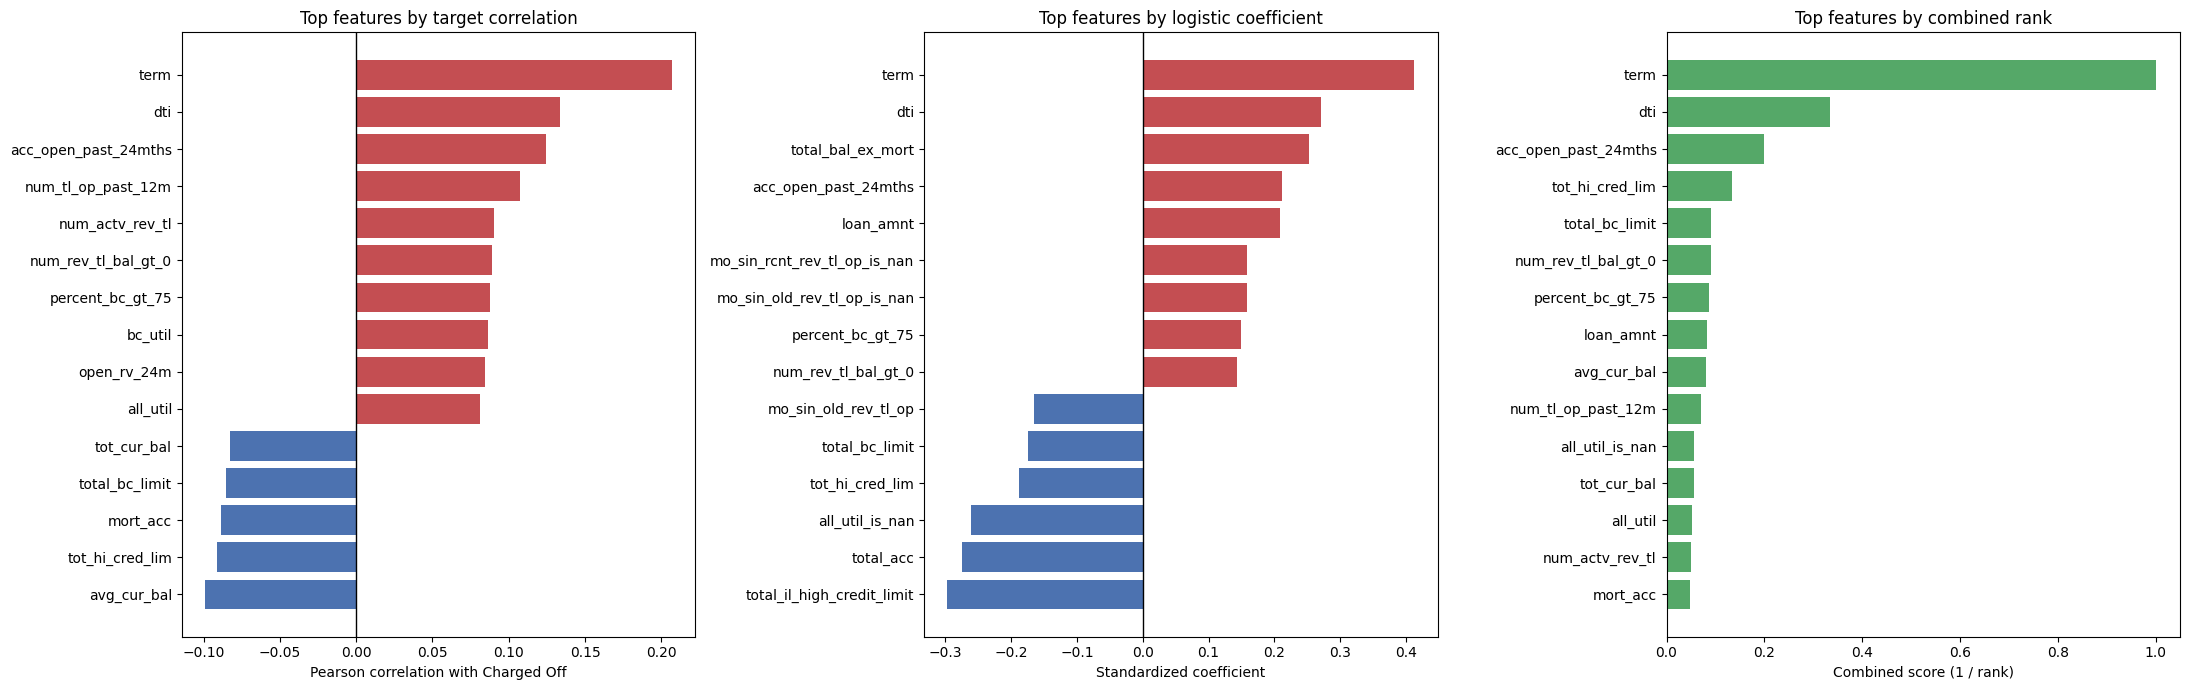

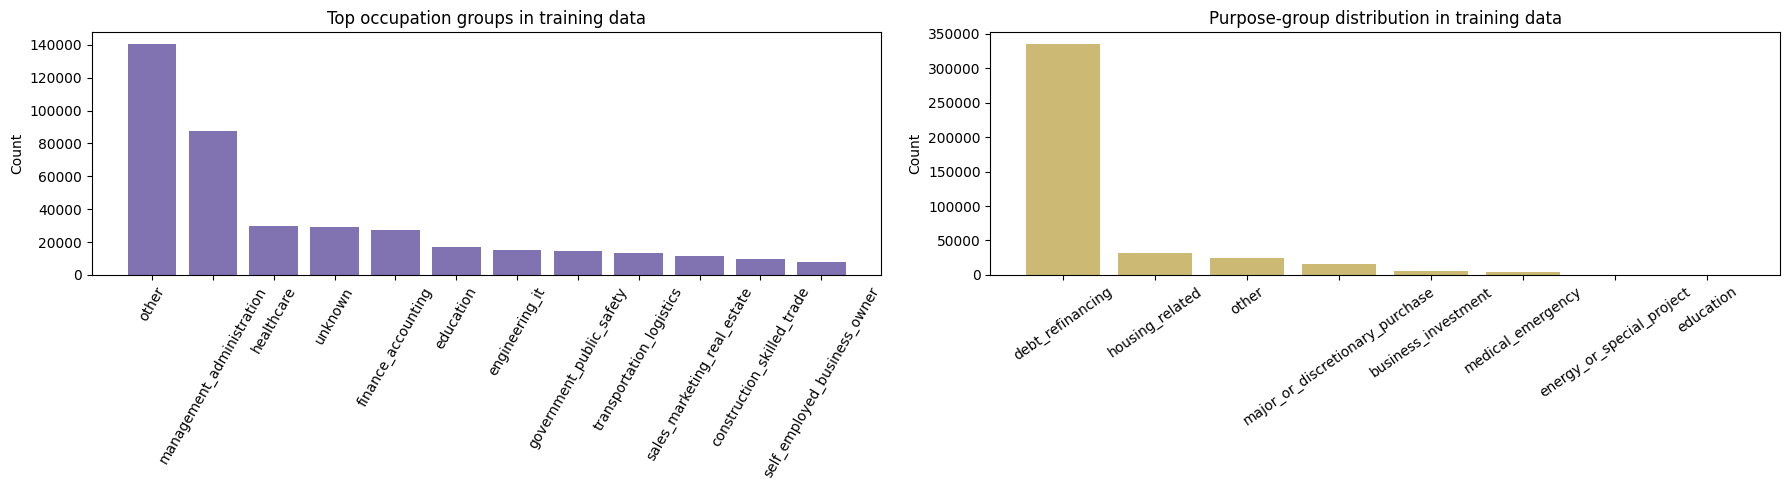

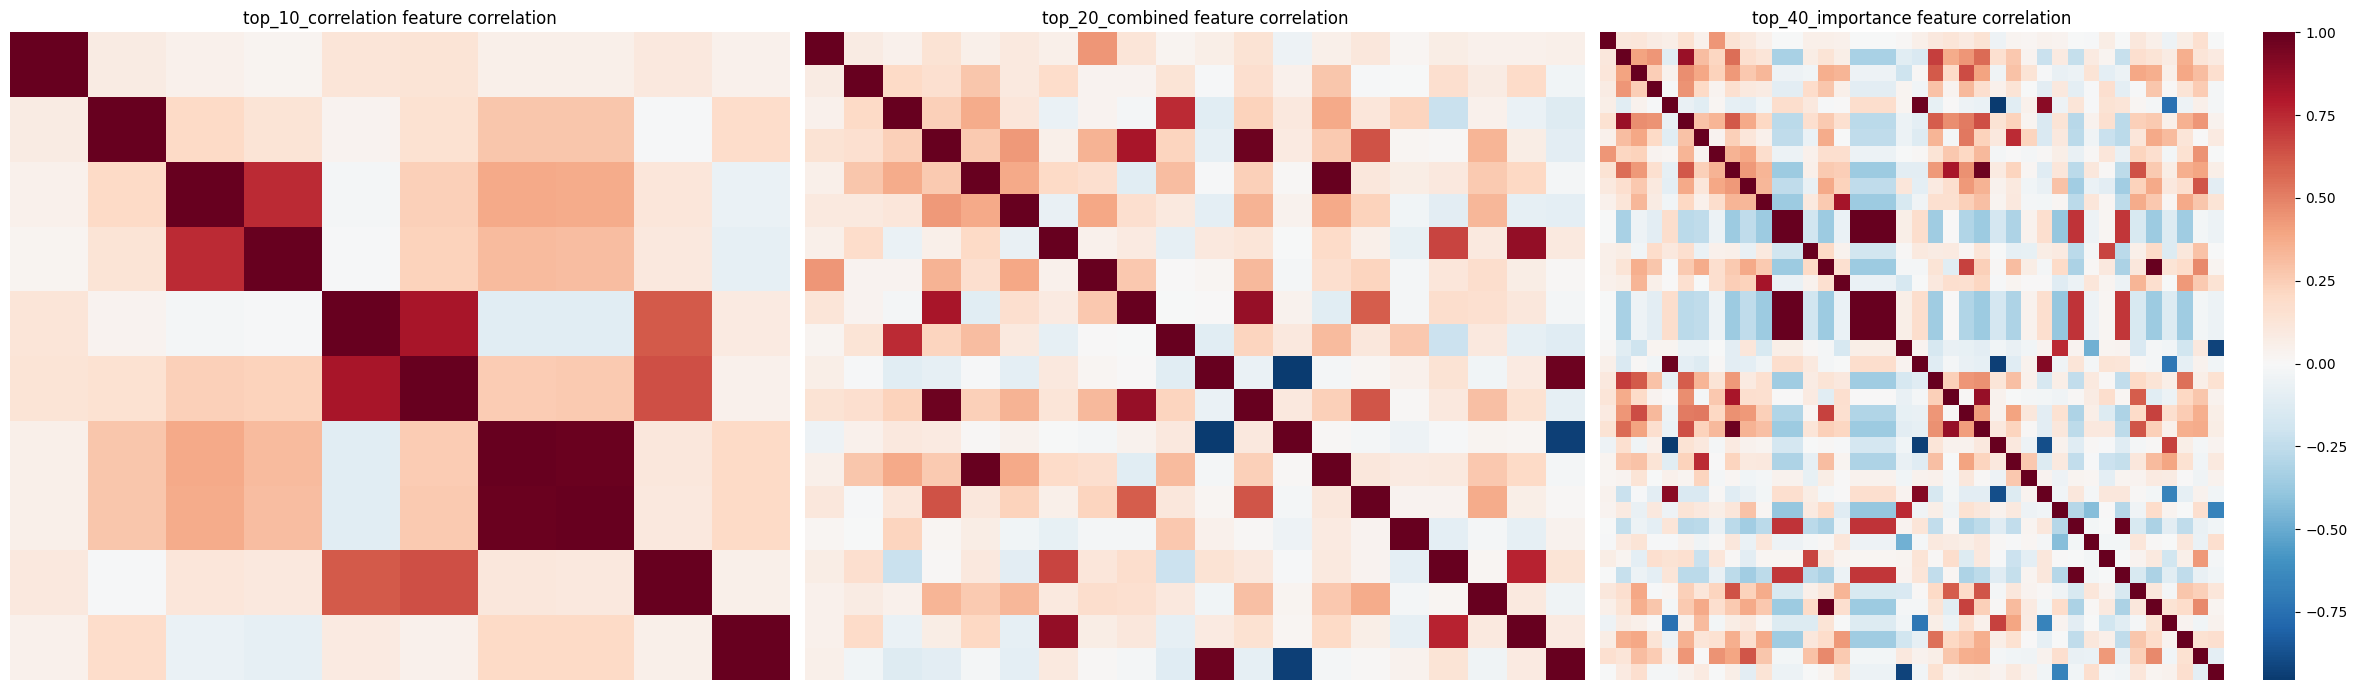

In [89]:
top_n = 15

correlation_plot_df = feature_ranking_by_correlation.head(top_n).sort_values("correlation")
importance_plot_df = feature_ranking_by_importance.head(top_n).sort_values("coefficient")
combined_plot_df = feature_ranking_by_combined.head(top_n).copy()
combined_plot_df["combined_score"] = 1 / combined_plot_df["combined_rank"]
combined_plot_df = combined_plot_df.sort_values("combined_score")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

corr_colors = ["#C44E52" if value > 0 else "#4C72B0" for value in correlation_plot_df["correlation"]]
axes[0].barh(correlation_plot_df["feature"], correlation_plot_df["correlation"], color=corr_colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Top features by target correlation")
axes[0].set_xlabel("Pearson correlation with Charged Off")

coef_colors = ["#C44E52" if value > 0 else "#4C72B0" for value in importance_plot_df["coefficient"]]
axes[1].barh(importance_plot_df["feature"], importance_plot_df["coefficient"], color=coef_colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Top features by logistic coefficient")
axes[1].set_xlabel("Standardized coefficient")

axes[2].barh(combined_plot_df["feature"], combined_plot_df["combined_score"], color="#55A868")
axes[2].set_title("Top features by combined rank")
axes[2].set_xlabel("Combined score (1 / rank)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

occupation_counts = X_train_cat_ready["occupation_group"].value_counts().head(12)
axes[0].bar(occupation_counts.index.astype(str), occupation_counts.values, color="#8172B2")
axes[0].set_title("Top occupation groups in training data")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=60)

purpose_counts = X_train_cat_ready["purpose_group"].value_counts()
axes[1].bar(purpose_counts.index.astype(str), purpose_counts.values, color="#CCB974")
axes[1].set_title("Purpose-group distribution in training data")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

heatmap_feature_sets = ["top_10_correlation", "top_20_combined", "top_40_importance"]
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, feature_set_name in zip(axes, heatmap_feature_sets):
    numeric_features = [column for column in catboost_feature_sets[feature_set_name] if column not in CATBOOST_BRANCH_CATEGORICAL_COLUMNS]
    subset_corr = X_train_cat_ready[numeric_features].corr(method="spearman")
    sns.heatmap(subset_corr, cmap="RdBu_r", center=0, ax=ax, cbar=(feature_set_name == heatmap_feature_sets[-1]), xticklabels=False, yticklabels=False)
    ax.set_title(f"{feature_set_name} feature correlation")

plt.tight_layout()
plt.show()


### Step 10: Train and compare the four CatBoost subset models
Using the train/test split already created in this notebook, we train one native `CatBoost` model for each subset from Step 8 and compare their performance with the same metrics used throughout the project.


In [90]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_cat_binary = Y_train_cat.map({"Fully Paid": 0, "Charged Off": 1}).astype(int)
y_test_cat_binary = Y_test_cat.map({"Fully Paid": 0, "Charged Off": 1}).astype(int)

catboost_subset_results = []
catboost_subset_predictions = {}

for subset_name, subset_columns in catboost_feature_sets.items():
    X_train_subset = X_train_cat_ready[subset_columns].copy()
    X_test_subset = X_test_cat_ready[subset_columns].copy()
    subset_cat_columns = [column for column in CATBOOST_BRANCH_CATEGORICAL_COLUMNS if column in subset_columns]

    model = CatBoostClassifier(
        depth=6,
        iterations=500,
        learning_rate=0.05,
        l2_leaf_reg=3,
        loss_function="Logloss",
        verbose=0,
        random_state=42,
        cat_features=subset_cat_columns,
    )

    model.fit(X_train_subset, y_train_cat_binary)
    predictions = pd.Series(model.predict(X_test_subset).reshape(-1), index=X_test_subset.index).astype(int)
    catboost_subset_predictions[subset_name] = predictions

    catboost_subset_results.append({
        "subset_name": subset_name,
        "feature_count": len(subset_columns),
        "categorical_feature_count": len(subset_cat_columns),
        "accuracy": float(accuracy_score(y_test_cat_binary, predictions)),
        "precision": float(precision_score(y_test_cat_binary, predictions, zero_division=0)),
        "recall": float(recall_score(y_test_cat_binary, predictions, zero_division=0)),
        "weighted_f1": float(f1_score(y_test_cat_binary, predictions, average="weighted", zero_division=0)),
        "positive_f1": float(f1_score(y_test_cat_binary, predictions, average="binary", zero_division=0)),
    })

catboost_subset_results_df = pd.DataFrame(catboost_subset_results).sort_values(
    ["weighted_f1", "positive_f1", "recall", "precision"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

display(catboost_subset_results_df)
best_catboost_subset_name = catboost_subset_results_df.loc[0, "subset_name"]
print(f"Best CatBoost subset: {best_catboost_subset_name}")


,subset_name,feature_count,categorical_feature_count,accuracy,precision,recall,weighted_f1,positive_f1
0,full_native_grouped,99,4,0.666304,0.665158,0.671670,0.666294,0.668398
1,top_40_importance,44,4,0.662508,0.662304,0.665079,0.662506,0.663689
2,top_20_combined,24,4,0.660095,0.659641,0.663498,0.660091,0.661564
3,top_10_correlation,14,4,0.643195,0.644554,0.640736,0.643193,0.642639


Best CatBoost subset: full_native_grouped


### Step 11: PCA dimensionality-reduction experiment
This is a separate end experiment, not part of the final main pipeline. We apply PCA only to the numeric CatBoost-branch features, keep the categorical columns unchanged, and test whether a smaller number of principal components can match or improve the earlier subset results with fewer numeric dimensions.


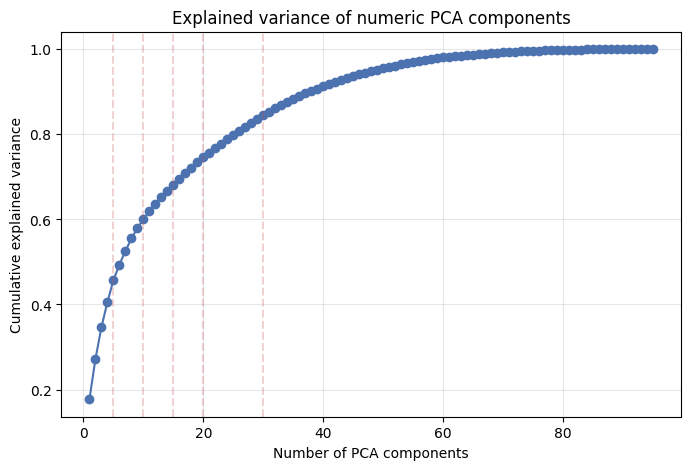

,model_name,numeric_component_count,categorical_feature_count,total_feature_count,explained_variance,accuracy,precision,recall,weighted_f1,positive_f1
0,pca_30_components,30,4,34,0.844728,0.655956,0.656492,0.656279,0.655956,0.656385
1,pca_20_components,20,4,24,0.745298,0.649118,0.649124,0.651251,0.649116,0.650185
2,pca_15_components,15,4,19,0.681367,0.618732,0.615205,0.636907,0.618603,0.625868
3,pca_10_components,10,4,14,0.600640,0.615184,0.611434,0.634984,0.615030,0.622986
4,pca_5_components,5,4,9,0.457420,0.588069,0.585950,0.604354,0.587958,0.595010


,model_name,total_feature_count,numeric_component_count,explained_variance,accuracy,precision,recall,weighted_f1,positive_f1
0,full_native_grouped,99,NaN,NaN,0.666228,0.665332,0.670832,0.666220,0.668070
1,top_20_combined,24,NaN,NaN,0.660486,0.660069,0.663765,0.660482,0.661912
2,pca_30_components,34,30.0,0.844728,0.655956,0.656492,0.656279,0.655956,0.656385
3,pca_20_components,24,20.0,0.745298,0.649118,0.649124,0.651251,0.649116,0.650185
4,pca_15_components,19,15.0,0.681367,0.618732,0.615205,0.636907,0.618603,0.625868
5,pca_10_components,14,10.0,0.600640,0.615184,0.611434,0.634984,0.615030,0.622986
6,pca_5_components,9,5.0,0.457420,0.588069,0.585950,0.604354,0.587958,0.595010


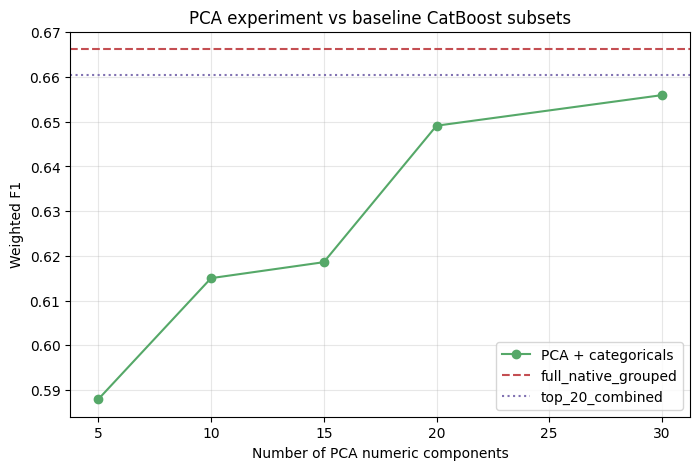

In [107]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_numeric_columns = [column for column in X_train_cat_ready.columns if column not in CATBOOST_BRANCH_CATEGORICAL_COLUMNS]
pca_component_candidates = [5, 10, 15, 20, 30]
pca_component_candidates = [n for n in pca_component_candidates if n <= len(pca_numeric_columns)]

pca_scaler = StandardScaler()
X_train_numeric_scaled = pca_scaler.fit_transform(X_train_cat_ready[pca_numeric_columns])
X_test_numeric_scaled = pca_scaler.transform(X_test_cat_ready[pca_numeric_columns])

pca_full = PCA()
pca_full.fit(X_train_numeric_scaled)
cumulative_explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker="o", color="#4C72B0")
for n in pca_component_candidates:
    plt.axvline(n, color="#C44E52", linestyle="--", alpha=0.25)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("Explained variance of numeric PCA components")
plt.grid(True, alpha=0.3)
plt.show()

pca_results = []

for n_components in pca_component_candidates:
    pca = PCA(n_components=n_components)
    X_train_components = pca.fit_transform(X_train_numeric_scaled)
    X_test_components = pca.transform(X_test_numeric_scaled)

    component_names = [f"PC{i + 1}" for i in range(n_components)]
    X_train_pca_df = pd.DataFrame(X_train_components, columns=component_names, index=X_train_cat_ready.index)
    X_test_pca_df = pd.DataFrame(X_test_components, columns=component_names, index=X_test_cat_ready.index)

    X_train_pca_model = pd.concat([X_train_pca_df, X_train_cat_ready[CATBOOST_BRANCH_CATEGORICAL_COLUMNS].copy()], axis=1)
    X_test_pca_model = pd.concat([X_test_pca_df, X_test_cat_ready[CATBOOST_BRANCH_CATEGORICAL_COLUMNS].copy()], axis=1)

    pca_model = CatBoostClassifier(
        depth=6,
        iterations=500,
        learning_rate=0.05,
        l2_leaf_reg=3,
        loss_function="Logloss",
        verbose=0,
        random_state=42,
        cat_features=CATBOOST_BRANCH_CATEGORICAL_COLUMNS,
    )

    pca_model.fit(X_train_pca_model, y_train_cat_binary)
    pca_predictions = pd.Series(pca_model.predict(X_test_pca_model).reshape(-1), index=X_test_pca_model.index).astype(int)

    pca_results.append({
        "model_name": f"pca_{n_components}_components",
        "numeric_component_count": n_components,
        "categorical_feature_count": len(CATBOOST_BRANCH_CATEGORICAL_COLUMNS),
        "total_feature_count": n_components + len(CATBOOST_BRANCH_CATEGORICAL_COLUMNS),
        "explained_variance": float(pca.explained_variance_ratio_.sum()),
        "accuracy": float(accuracy_score(y_test_cat_binary, pca_predictions)),
        "precision": float(precision_score(y_test_cat_binary, pca_predictions, zero_division=0)),
        "recall": float(recall_score(y_test_cat_binary, pca_predictions, zero_division=0)),
        "weighted_f1": float(f1_score(y_test_cat_binary, pca_predictions, average="weighted", zero_division=0)),
        "positive_f1": float(f1_score(y_test_cat_binary, pca_predictions, average="binary", zero_division=0)),
    })

pca_results_df = pd.DataFrame(pca_results).sort_values(
    ["weighted_f1", "positive_f1", "recall", "precision"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

comparison_rows = catboost_subset_results_df[catboost_subset_results_df["subset_name"].isin(["top_20_combined", "full_native_grouped"])].copy()
comparison_rows["model_name"] = comparison_rows["subset_name"]
comparison_rows["numeric_component_count"] = np.nan
comparison_rows["explained_variance"] = np.nan
comparison_rows["total_feature_count"] = comparison_rows["feature_count"]

pca_comparison_df = pd.concat([
    comparison_rows[["model_name", "total_feature_count", "numeric_component_count", "explained_variance", "accuracy", "precision", "recall", "weighted_f1", "positive_f1"]],
    pca_results_df[["model_name", "total_feature_count", "numeric_component_count", "explained_variance", "accuracy", "precision", "recall", "weighted_f1", "positive_f1"]]
], ignore_index=True)

display(pca_results_df)
display(pca_comparison_df)

plt.figure(figsize=(8, 5))
plt.plot(pca_results_df["numeric_component_count"], pca_results_df["weighted_f1"], marker="o", color="#55A868", label="PCA + categoricals")
if "full_native_grouped" in set(catboost_subset_results_df["subset_name"]):
    plt.axhline(
        catboost_subset_results_df.loc[catboost_subset_results_df["subset_name"] == "full_native_grouped", "weighted_f1"].iloc[0],
        color="#C44E52",
        linestyle="--",
        label="full_native_grouped"
    )
if "top_20_combined" in set(catboost_subset_results_df["subset_name"]):
    plt.axhline(
        catboost_subset_results_df.loc[catboost_subset_results_df["subset_name"] == "top_20_combined", "weighted_f1"].iloc[0],
        color="#8172B2",
        linestyle=":",
        label="top_20_combined"
    )
plt.xlabel("Number of PCA numeric components")
plt.ylabel("Weighted F1")
plt.title("PCA experiment vs baseline CatBoost subsets")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
